# Lab Assignment 3: GridWorld – Policy Evaluation and Value Iteration

**Course:** Reinforcement Learning  
**Experiment:** GridWorld – Policy Evaluation and Value Iteration

## Objectives

1. Formulate GridWorld as a Markov Decision Process (MDP).
2. Implement iterative **Policy Evaluation** for a fixed policy.
3. Observe the value function as it converges.
4. Implement **Value Iteration** using the Bellman optimality equation.
5. Derive and visualize the optimal policy.
6. Compare Random, Evaluated, and Optimal policies using:
   - path,
   - number of steps,
   - cumulative reward,
   - goal achievement.

> **Note:** This notebook uses a self-contained deterministic 4×4 GridWorld so that the algorithms are implemented directly rather than hidden behind a library environment.


NAME PRABHU TEJAS
REG. NO: BL.EN.R4AIE26008
EMAIL: BL.EN.R4AIE26008@BL.STUDENTS.AMRITA.EDU


## 1. GridWorld Environment

We use the following deterministic GridWorld:

```text
+-----+-----+-----+-----+
|  S  |     |     |     |
+-----+-----+-----+-----+
|     |  X  |     |     |
+-----+-----+-----+-----+
|     |     |     |     |
+-----+-----+-----+-----+
|     |     |     |  G  |
+-----+-----+-----+-----+
```

- `S` = start state `(0,0)`
- `G` = terminal goal `(3,3)`
- `X` = obstacle `(1,1)`
- Actions = Up, Down, Left, Right
- Normal movement reward = `-1`
- Reaching goal reward = `+10`
- Discount factor `γ = 0.9`
- Invalid moves keep the agent in the same state and receive `-1`


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import random

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# GridWorld configuration
ROWS, COLS = 4, 4
START = (0, 0)
GOAL = (3, 3)
OBSTACLES = {(1, 1)}

ACTIONS = {
    "U": (-1, 0),
    "D": (1, 0),
    "L": (0, -1),
    "R": (0, 1),
}

ARROWS = {
    "U": "↑",
    "D": "↓",
    "L": "←",
    "R": "→",
    "G": "G",
}

GAMMA = 0.9
THETA = 1e-4
MAX_EPISODE_STEPS = 100

def get_states():
    return [
        (r, c)
        for r in range(ROWS)
        for c in range(COLS)
        if (r, c) not in OBSTACLES
    ]

STATES = get_states()

print("States:", len(STATES))
print("Start:", START)
print("Goal:", GOAL)
print("Obstacles:", OBSTACLES)
print("Actions:", list(ACTIONS))


States: 15
Start: (0, 0)
Goal: (3, 3)
Obstacles: {(1, 1)}
Actions: ['U', 'D', 'L', 'R']


In [2]:
def get_next_state(state, action):
    """Deterministic transition function T(s,a)."""
    if state == GOAL:
        return state

    r, c = state
    dr, dc = ACTIONS[action]
    nr, nc = r + dr, c + dc

    # Boundary check
    if nr < 0 or nr >= ROWS or nc < 0 or nc >= COLS:
        return state

    # Obstacle check
    if (nr, nc) in OBSTACLES:
        return state

    return (nr, nc)


def get_reward(state, action, next_state):
    """Reward function R(s,a,s')."""
    if next_state == GOAL:
        return 10.0
    return -1.0


def print_grid_policy(policy, title=None):
    if title:
        print(title)
    for r in range(ROWS):
        row = []
        for c in range(COLS):
            s = (r, c)
            if s in OBSTACLES:
                row.append(" X ")
            elif s == GOAL:
                row.append(" G ")
            else:
                row.append(f" {ARROWS[policy[s]]} ")
        print("|".join(row))


def print_value_grid(V, decimals=2, title=None):
    if title:
        print(title)
    for r in range(ROWS):
        row = []
        for c in range(COLS):
            s = (r, c)
            if s in OBSTACLES:
                row.append("   X   ")
            elif s == GOAL:
                row.append("   G   ")
            else:
                row.append(f"{V[s]:7.{decimals}f}")
        print(" ".join(row))


## 2. MDP Formulation

The environment is an MDP:

\[
M=(S,A,P,R,\gamma)
\]

| Component | Definition |
|---|---|
| State space `S` | All non-obstacle grid cells |
| Action space `A` | `{U, D, L, R}` |
| Transition `P(s'|s,a)` | Deterministic transition to the resulting cell |
| Reward `R(s,a,s')` | `+10` when reaching goal, otherwise `-1` |
| Discount `γ` | `0.9` |
| Terminal state | `(3,3)` |

The objective is to maximize expected discounted return:

\[
G_t = R_{t+1}+\gamma R_{t+2}+\gamma^2R_{t+3}+\cdots
\]


In [3]:
# Verify a few transitions
examples = [
    ((0, 0), "R"),
    ((0, 0), "U"),  # boundary
    ((1, 0), "R"),  # obstacle, so remains in place
    ((2, 3), "D"),  # reaches goal
]

for state, action in examples:
    ns = get_next_state(state, action)
    reward = get_reward(state, action, ns)
    print(f"{state} --{action}--> {ns}, reward={reward}")


(0, 0) --R--> (0, 1), reward=-1.0
(0, 0) --U--> (0, 0), reward=-1.0
(1, 0) --R--> (1, 0), reward=-1.0
(2, 3) --D--> (3, 3), reward=10.0


## 3. A Fixed Goal-Directed Policy

For Policy Evaluation, a policy must first be specified.

The policy below moves right whenever possible and otherwise moves down. It is intentionally simple and is evaluated rather than assumed to be optimal.


In [4]:
def make_goal_directed_policy():
    policy = {}
    for state in STATES:
        if state == GOAL:
            policy[state] = "G"
        elif state[1] < COLS - 1:
            policy[state] = "R"
        else:
            policy[state] = "D"
    return policy

evaluated_policy = make_goal_directed_policy()

print_grid_policy(evaluated_policy, "Fixed policy used for Policy Evaluation:")


Fixed policy used for Policy Evaluation:
 → | → | → | ↓ 
 → | X | → | ↓ 
 → | → | → | ↓ 
 → | → | → | G 


## 4. Policy Evaluation

For a fixed policy `π`, the Bellman expectation equation is:

\[
V^\pi(s)
=
\sum_a \pi(a|s)
\sum_{s'} P(s'|s,a)
\left[R(s,a,s')+\gamma V^\pi(s')\right]
\]

Because this environment and the policy are deterministic:

\[
V^\pi(s)
=
R(s,\pi(s),s')+\gamma V^\pi(s')
\]

We start with:

\[
V_0(s)=0
\]

and repeatedly update until:

\[
\max_s |V_{k+1}(s)-V_k(s)| < \theta
\]

where `θ = 0.0001`.


In [5]:
def policy_evaluation(policy, gamma=GAMMA, theta=THETA):
    V = {state: 0.0 for state in STATES}
    history = [V.copy()]
    deltas = []

    iteration = 0
    while True:
        new_V = V.copy()
        delta = 0.0

        for state in STATES:
            if state == GOAL:
                continue

            action = policy[state]
            next_state = get_next_state(state, action)
            reward = get_reward(state, action, next_state)

            new_value = reward + gamma * V[next_state]
            delta = max(delta, abs(new_value - V[state]))
            new_V[state] = new_value

        V = new_V
        history.append(V.copy())
        deltas.append(delta)
        iteration += 1

        if delta < theta:
            break

    return V, history, deltas

V_pi, policy_history, policy_deltas = policy_evaluation(evaluated_policy)

print(f"Policy Evaluation converged after {len(policy_deltas)} iterations.")
print_value_grid(V_pi, title="Converged V^π:")


Policy Evaluation converged after 89 iterations.
Converged V^π:
   1.81    3.12    4.58    6.20
 -10.00    X       6.20    8.00
   4.58    6.20    8.00   10.00
   6.20    8.00   10.00    G   


In [6]:
# Observation table for selected Policy Evaluation iterations
selected_iterations = [0, 1, 2, 3, 4, 5, 10, len(policy_history)-1]
selected_iterations = sorted(set(i for i in selected_iterations if i < len(policy_history)))

rows = []
for i in selected_iterations:
    V = policy_history[i]
    rows.append({
        "Iteration": i,
        "V(0,0)": round(V[START], 4),
        "V(0,3)": round(V[(0,3)], 4),
        "V(2,3)": round(V[(2,3)], 4),
        "V(3,2)": round(V[(3,2)], 4),
        "Max Δ": "-" if i == 0 else round(policy_deltas[i-1], 6)
    })

policy_observation_df = pd.DataFrame(rows)
display(policy_observation_df)


,Iteration,"V(0,0)","V(0,3)","V(2,3)","V(3,2)",Max Δ
0,0,0.0000,0.0,0.0,0.0,-
1,1,-1.0000,-1.0,10.0,10.0,10.0
2,2,-1.9000,-1.9,10.0,10.0,9.0
3,3,-2.7100,6.2,10.0,10.0,8.1
4,4,-3.4390,6.2,10.0,10.0,7.29
5,5,-4.0951,6.2,10.0,10.0,6.561
6,10,1.8098,6.2,10.0,10.0,0.38742
7,89,1.8098,6.2,10.0,10.0,0.000094


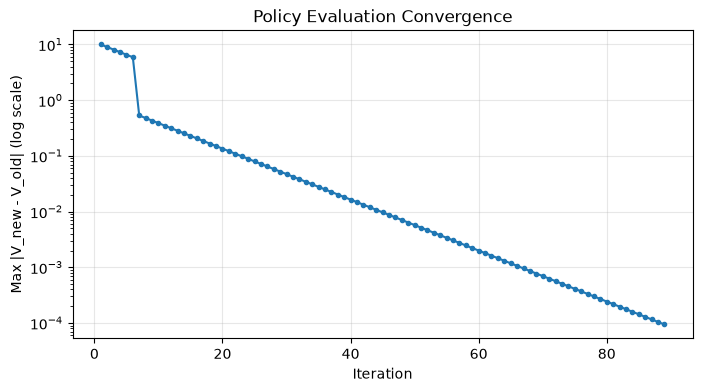

In [7]:
# Plot convergence of the maximum Bellman update
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(policy_deltas) + 1), policy_deltas, marker="o", markersize=3)
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Max |V_new - V_old| (log scale)")
plt.title("Policy Evaluation Convergence")
plt.grid(True, alpha=0.3)
plt.show()


### Observation

The value function starts at zero and reward information propagates backward from the terminal state. The maximum change between successive iterations decreases until it falls below the convergence threshold.

This illustrates why iterative dynamic programming can evaluate a policy without simulating thousands of episodes: the Bellman equation directly propagates expected future return through the known model.


## 5. Value Iteration

Value Iteration uses the Bellman optimality equation:

\[
V^*(s)
=
\max_a
\sum_{s'}P(s'|s,a)
\left[R(s,a,s')+\gamma V^*(s')\right]
\]

For our deterministic GridWorld:

\[
V_{k+1}(s)
=
\max_a
\left[R(s,a,s')+\gamma V_k(s')\right]
\]

The optimal policy is subsequently obtained using:

\[
\pi^*(s)
=
\arg\max_a
\left[R(s,a,s')+\gamma V^*(s')\right]
\]


In [8]:
def value_iteration(gamma=GAMMA, theta=THETA):
    V = {state: 0.0 for state in STATES}
    history = [V.copy()]
    deltas = []

    while True:
        new_V = V.copy()
        delta = 0.0

        for state in STATES:
            if state == GOAL:
                continue

            action_values = []
            for action in ACTIONS:
                next_state = get_next_state(state, action)
                reward = get_reward(state, action, next_state)
                q_value = reward + gamma * V[next_state]
                action_values.append(q_value)

            new_value = max(action_values)
            delta = max(delta, abs(new_value - V[state]))
            new_V[state] = new_value

        V = new_V
        history.append(V.copy())
        deltas.append(delta)

        if delta < theta:
            break

    return V, history, deltas


V_star, value_history, value_deltas = value_iteration()

print(f"Value Iteration converged after {len(value_deltas)} iterations.")
print_value_grid(V_star, title="Optimal value function V*:")


Value Iteration converged after 7 iterations.
Optimal value function V*:
   1.81    3.12    4.58    6.20
   3.12    X       6.20    8.00
   4.58    6.20    8.00   10.00
   6.20    8.00   10.00    G   


In [9]:
def extract_optimal_policy(V, gamma=GAMMA):
    policy = {}

    for state in STATES:
        if state == GOAL:
            policy[state] = "G"
            continue

        best_value = float("-inf")
        best_actions = []

        for action in ACTIONS:
            next_state = get_next_state(state, action)
            reward = get_reward(state, action, next_state)
            q_value = reward + gamma * V[next_state]

            if q_value > best_value + 1e-12:
                best_value = q_value
                best_actions = [action]
            elif abs(q_value - best_value) <= 1e-12:
                best_actions.append(action)

        # Deterministic tie-breaking for a clean visualization
        policy[state] = best_actions[0]

    return policy

optimal_policy = extract_optimal_policy(V_star)

print_grid_policy(optimal_policy, "Optimal policy π*:")


Optimal policy π*:
 ↓ | → | ↓ | ↓ 
 ↓ | X | ↓ | ↓ 
 ↓ | ↓ | ↓ | ↓ 
 → | → | → | G 


In [10]:
# Value Iteration observation table
selected_iterations = [0, 1, 2, 3, 4, 5, 10, len(value_history)-1]
selected_iterations = sorted(set(i for i in selected_iterations if i < len(value_history)))

rows = []
for i in selected_iterations:
    V = value_history[i]
    rows.append({
        "Iteration": i,
        "V*(0,0)": round(V[START], 4),
        "V*(0,3)": round(V[(0,3)], 4),
        "V*(2,3)": round(V[(2,3)], 4),
        "V*(3,2)": round(V[(3,2)], 4),
        "Max Δ": "-" if i == 0 else round(value_deltas[i-1], 6)
    })

value_observation_df = pd.DataFrame(rows)
display(value_observation_df)


,Iteration,"V*(0,0)","V*(0,3)","V*(2,3)","V*(3,2)",Max Δ
0,0,0.0000,0.0,0.0,0.0,-
1,1,-1.0000,-1.0,10.0,10.0,10.0
2,2,-1.9000,-1.9,10.0,10.0,9.0
3,3,-2.7100,6.2,10.0,10.0,8.1
4,4,-3.4390,6.2,10.0,10.0,7.29
5,5,-4.0951,6.2,10.0,10.0,6.561
6,7,1.8098,6.2,10.0,10.0,0.0


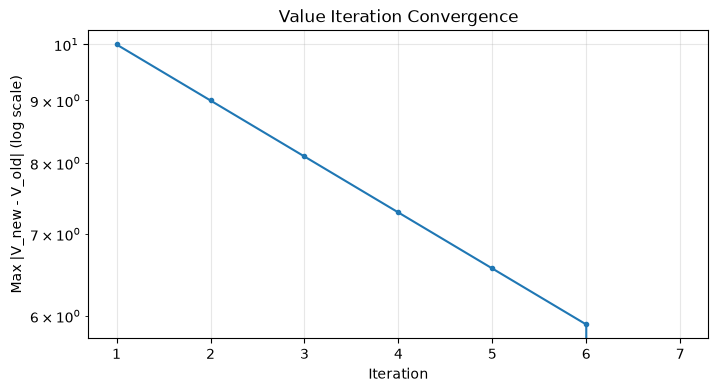

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(value_deltas) + 1), value_deltas, marker="o", markersize=3)
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Max |V_new - V_old| (log scale)")
plt.title("Value Iteration Convergence")
plt.grid(True, alpha=0.3)
plt.show()


## 6. Policy Execution

We now execute three policies:

1. **Random Policy** – randomly selects a valid action at each state.
2. **Evaluated Policy** – the fixed policy used in Policy Evaluation.
3. **Optimal Policy** – extracted from Value Iteration.

For each execution we record:

- path,
- number of steps,
- total cumulative reward,
- whether the goal was reached.

Because a random policy is stochastic, multiple runs can have different results. A fixed seed is used for the demonstration, and a separate repeated experiment is also included.


In [12]:
def random_action_policy():
    # Returns a policy mapping for reproducible one-episode comparison.
    policy = {}
    for state in STATES:
        if state == GOAL:
            policy[state] = "G"
        else:
            policy[state] = random.choice(list(ACTIONS.keys()))
    return policy


def run_episode(policy, max_steps=MAX_EPISODE_STEPS):
    state = START
    path = [state]
    total_reward = 0.0

    for _ in range(max_steps):
        if state == GOAL:
            break

        action = policy[state]
        next_state = get_next_state(state, action)
        reward = get_reward(state, action, next_state)

        total_reward += reward
        state = next_state
        path.append(state)

        if state == GOAL:
            break

    return {
        "path": path,
        "steps": len(path) - 1,
        "reward": total_reward,
        "goal_reached": state == GOAL
    }


# One reproducible random-policy run
random.seed(RANDOM_SEED)
random_policy = random_action_policy()

result_random = run_episode(random_policy)
result_evaluated = run_episode(evaluated_policy)
result_optimal = run_episode(optimal_policy)

for name, result in [
    ("Random", result_random),
    ("Evaluated", result_evaluated),
    ("Optimal", result_optimal),
]:
    print(f"\n{name} Policy")
    print("Path:", result["path"])
    print("Steps:", result["steps"])
    print("Reward:", result["reward"])
    print("Goal reached:", result["goal_reached"])



Random Policy
Path: [(0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0)]
Steps: 100
Reward: -100.0
Goal reached: False

Evaluated Policy
Path: [(0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (2, 3), (3, 3)]
Steps: 6
Reward: 5.0
Goal reached: True

Op

In [13]:
# Compact comparison table
comparison_df = pd.DataFrame([
    {
        "Policy": "Random",
        "Path": " → ".join(map(str, result_random["path"])),
        "Steps": result_random["steps"],
        "Cumulative Reward": result_random["reward"],
        "Goal Reached": result_random["goal_reached"],
    },
    {
        "Policy": "Evaluated",
        "Path": " → ".join(map(str, result_evaluated["path"])),
        "Steps": result_evaluated["steps"],
        "Cumulative Reward": result_evaluated["reward"],
        "Goal Reached": result_evaluated["goal_reached"],
    },
    {
        "Policy": "Optimal",
        "Path": " → ".join(map(str, result_optimal["path"])),
        "Steps": result_optimal["steps"],
        "Cumulative Reward": result_optimal["reward"],
        "Goal Reached": result_optimal["goal_reached"],
    },
])

display(comparison_df)


,Policy,Path,Steps,Cumulative Reward,Goal Reached
0,Random,"(0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (...",100,-100.0,False
1,Evaluated,"(0, 0) → (0, 1) → (0, 2) → (0, 3) → (1, 3) → (...",6,5.0,True
2,Optimal,"(0, 0) → (1, 0) → (2, 0) → (3, 0) → (3, 1) → (...",6,5.0,True


## 7. Repeated Random-Policy Experiment

A single random episode can be misleading. To demonstrate the stochastic nature of the random policy, we repeat it many times.

We report:

- success rate,
- average steps among successful episodes,
- average reward,
- average steps overall.

This gives a more meaningful comparison than one random trajectory.


In [14]:
def run_random_episode():
    state = START
    path = [state]
    total_reward = 0.0

    for _ in range(MAX_EPISODE_STEPS):
        if state == GOAL:
            break

        action = random.choice(list(ACTIONS.keys()))
        next_state = get_next_state(state, action)
        reward = get_reward(state, action, next_state)

        total_reward += reward
        state = next_state
        path.append(state)

        if state == GOAL:
            break

    return {
        "steps": len(path) - 1,
        "reward": total_reward,
        "goal_reached": state == GOAL
    }


random.seed(RANDOM_SEED)
N_RANDOM_RUNS = 1000
random_results = [run_random_episode() for _ in range(N_RANDOM_RUNS)]

random_success_rate = np.mean([r["goal_reached"] for r in random_results])
random_avg_steps = np.mean([r["steps"] for r in random_results])
random_avg_reward = np.mean([r["reward"] for r in random_results])

successful_steps = [r["steps"] for r in random_results if r["goal_reached"]]
random_avg_success_steps = np.mean(successful_steps) if successful_steps else np.nan

random_summary = pd.DataFrame([{
    "Runs": N_RANDOM_RUNS,
    "Success Rate": random_success_rate,
    "Average Steps": random_avg_steps,
    "Average Reward": random_avg_reward,
    "Avg Steps | Successful": random_avg_success_steps,
}])

display(random_summary)


,Runs,Success Rate,Average Steps,Average Reward,Avg Steps | Successful
0,1000,0.853,50.919,-41.536,42.460727


## 8. Final Comparison and Interpretation

### Policy Evaluation

Policy Evaluation answers:

> **How good is the selected policy?**

It does not search over actions to find a better policy.

### Value Iteration

Value Iteration answers:

> **What is the maximum achievable value at each state under the MDP?**

It considers all available actions and uses the maximum action value.

### Random Policy

The random policy does not use value information. It can move away from the goal, revisit states, hit boundaries, and sometimes fail to reach the goal within the step limit.

### Optimal Policy

The optimal policy is derived from the converged optimal value function. Under the reward structure used here, each movement has a cost and reaching the goal provides a positive reward, so efficient routes generally have higher return.


## 9. Analysis Questions

### Q1. What is Policy Evaluation?

Policy Evaluation calculates the state-value function `V^π(s)` for a fixed policy.

### Q2. Why does the value function change over iterations?

The initial values are estimates. Each Bellman update incorporates the value of successor states, allowing reward information to propagate through the environment.

### Q3. What is Value Iteration?

Value Iteration repeatedly applies the Bellman optimality equation and takes the maximum over available actions to obtain the optimal value function.

### Q4. Why is `max()` used in Value Iteration?

Because the optimal value assumes that the agent chooses the action producing the highest expected return.

### Q5. Does Policy Evaluation automatically produce an optimal policy?

No. It evaluates the policy supplied to it. A policy improvement step is required to change the policy, or Value Iteration can be used directly.

### Q6. Why can the random policy require more steps?

It does not use information about the goal or long-term return. It can move in unhelpful directions or revisit states.

### Q7. Is the shortest geometric path always the optimal RL path?

Not necessarily. RL optimizes cumulative discounted reward, not geometric distance. The reward structure and discount factor determine which trajectory is optimal.

### Q8. What happens when `γ = 0`?

Only immediate reward matters; future rewards are ignored.

### Q9. What happens as `γ` approaches 1?

Future rewards become more important relative to immediate rewards.

### Q10. Why is a negative step reward useful?

It discourages unnecessary movement and, in this environment, encourages reaching the goal efficiently.


## 10. Conclusion

This experiment demonstrated GridWorld as a Markov Decision Process and implemented two fundamental dynamic programming algorithms: Policy Evaluation and Value Iteration. Policy Evaluation estimated the state-value function for a fixed policy, with reward information propagating through the grid until convergence.

Value Iteration instead applied the Bellman optimality equation and considered the best available action at each state. The resulting optimal value function was used to derive an optimal policy.

The execution comparison showed the conceptual difference between random and goal-directed decision making. A random policy can take inefficient trajectories or fail to reach the goal, while the optimal policy uses learned value information to select actions that maximize expected discounted return. The experiment also demonstrates that the shortest geometric route and the highest-return route are not universally identical; the reward function and discount factor determine the RL objective.

Overall, Policy Evaluation is primarily an **evaluation** procedure, whereas Value Iteration is an **optimization** procedure that directly leads to an optimal value function and corresponding policy.


## References

1. NeurOMatch Academy, *Basic Reinforcement Learning – GridWorld and Dynamic Programming*:
   https://deeplearning.neuromatch.io/tutorials/W3D4_BasicReinforcementLearning/student/W3D4_Tutorial1.html

2. Shangtong Zhang, *Reinforcement Learning: An Introduction – implementations*:
   https://github.com/ShangtongZhang/reinforcement-learning-an-introduction

3. Sutton, R. S., & Barto, A. G., *Reinforcement Learning: An Introduction*, 2nd ed.
